## Libraries Loaded
Import required libraries for data analysis, preprocessing, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import os

print("Libraries installed successfully!")

Libraries installed successfully!


## scripts/load_dataset.py
Load the PaySim dataset containing synthetic financial transaction records used for fraud detection analysis.

In [ ]:
def load_dataset(path):
    """
    Load dataset from CSV file
    """

    df = pd.read_csv(path)

    print("Dataset Loaded Successfully")
    print("Shape:", df.shape)

    return df


if __name__ == "__main__":

    dataset_path = "/content/PaySim - Synthetic Financial Dataset for Fraud Detection.csv"

    df = load_dataset(dataset_path)

    print(df.head())

Dataset Loaded Successfully
Shape: (6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


## scripts/basic_inspection.py
Perform initial dataset inspection including shape, column names, data types, and statistical summary to understand the dataset structure.

In [ ]:
def dataset_shape(df):
    """
    Display number of rows and columns
    """
    print("Dataset Shape:", df.shape)

In [ ]:
dataset_shape(df)

Dataset Shape: (6362620, 11)


In [ ]:
def dataset_columns(df):
    """
    Display column names
    """
    print("Columns:")
    print(df.columns)

In [ ]:
dataset_columns(df)

Columns:
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [ ]:
def dataset_datatypes(df):
    """
    Display datatypes of each column
    """
    print("Data Types:")
    print(df.dtypes)

In [ ]:
dataset_datatypes(df)

Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


In [ ]:
def dataset_head(df):
    """
    Display first rows
    """
    print("First 5 Rows:")
    print(df.head())

In [ ]:
dataset_head(df)

First 5 Rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
def dataset_description(df):
    """
    Statistical summary of dataset
    """
    print("Dataset Statistical Summary:")
    print(df.describe())

In [ ]:
dataset_description(df)

Dataset Statistical Summary:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  isFlaggedFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06    6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03    2.514687e-06  
std      3.399180e+06    3.674129e+06  3.590480e-02    1.585775e-03  
min      0.000000e+00    0.000000e+00  0.000000e+00    0.000000e+00  
25%     

In [ ]:
def missing_values(df):
    """
    Check missing values in dataset
    """
    print("Missing Values:")
    print(df.isnull().sum())

In [ ]:
missing_values(df)

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


## scripts/data_cleaning.py
Check for missing values to ensure data quality before performing preprocessing and analysis.

In [ ]:
def remove_duplicates(df):
    """
    Remove duplicate rows
    """

    before = df.shape[0]

    df = df.drop_duplicates()

    after = df.shape[0]

    print("Duplicates removed:", before - after)

    return df

In [ ]:
remove_duplicates(df)

Duplicates removed: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [ ]:
def check_outliers(df, column):
    """
    Detect outliers using IQR
    """

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

In [ ]:
check_outliers(df, "amount")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362609,742,CASH_OUT,258355.42,C1113162093,258355.42,0.00,C797688696,25176.67,283532.09,1,0
6362610,742,TRANSFER,63416.99,C778071008,63416.99,0.00,C1812552860,0.00,0.00,1,0
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.00,C1662241365,276433.18,339850.17,1,0
6362614,743,TRANSFER,339682.13,C2013999242,339682.13,0.00,C1850423904,0.00,0.00,1,0


## scripts/feature_engineering.py
Convert categorical variables into numerical form by using LabelEnoder so they can be used by machine learning models.

In [ ]:
def encode_transaction_type(df):
    """
    Convert transaction type into numeric values
    """

    encoder = LabelEncoder()

    df["type"] = encoder.fit_transform(df["type"])

    return df

In [ ]:
encode_transaction_type(df)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,3,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,4,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,1,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,3,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,4,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,1,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,4,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


## scripts/preprocessing_pipeline.py

Feature scaling was applied to numerical variables using StandardScaler to normalize the distribution of transaction-related variables. This step ensures that features with larger ranges do not dominate the learning process of machine learning models.


In [ ]:
def preprocess_data(df):

    df = remove_duplicates(df)

    df = encode_transaction_type(df)

    numerical_columns = [
        "amount",
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest"
    ]

    scaler = StandardScaler()

    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

    return df

In [ ]:
preprocess_data(df)

Duplicates removed: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,-0.281560,C1231006815,-0.229810,-0.237622,M1979787155,-0.323814,-0.333411,0,0
1,1,3,-0.294767,C1666544295,-0.281359,-0.285812,M2044282225,-0.323814,-0.333411,0,0
2,1,4,-0.297555,C1305486145,-0.288654,-0.292442,C553264065,-0.323814,-0.333411,1,0
3,1,1,-0.297555,C840083671,-0.288654,-0.292442,C38997010,-0.317582,-0.333411,1,0
4,1,3,-0.278532,C2048537720,-0.274329,-0.282221,M1230701703,-0.323814,-0.333411,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,1,0.264665,C786484425,-0.171108,-0.292442,C776919290,-0.323814,-0.240959,1,0
6362616,743,4,10.153953,C1529008245,1.896491,-0.292442,C1881841831,-0.323814,-0.333411,1,0
6362617,743,1,10.153953,C1162922333,1.896491,-0.292442,C1365125890,-0.303665,1.403027,1,0
6362618,743,4,1.109765,C1685995037,0.005581,-0.292442,C2080388513,-0.323814,-0.333411,1,0


In [ ]:
# Fraud vs Non-Fraud distribution
# Fraud detection datasets are typically highly imbalanced,
# meaning fraudulent transactions represent a very small
# percentage of the total transactions.

fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)

fraud_percentage = df["isFraud"].value_counts(normalize=True) * 100

print("\nFraud Percentage:")
print(fraud_percentage)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


Dataset Loaded Successfully
Shape: (6362620, 11)


Text(0.5, 1.0, 'After Scaling')

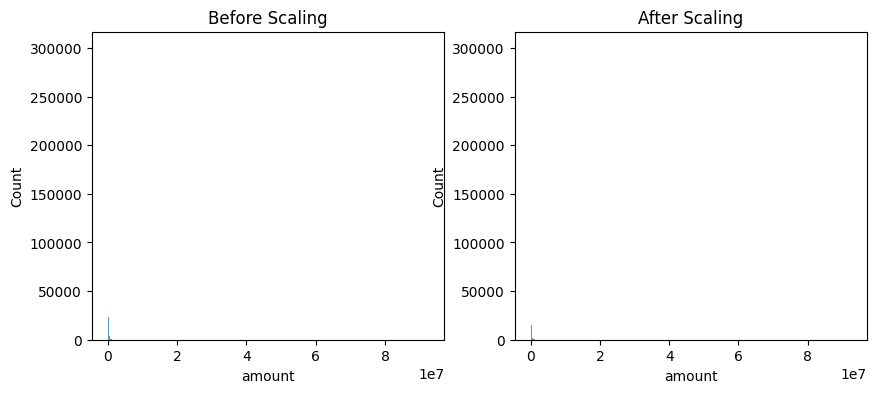

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
# Load a fresh copy of the dataset to show 'Before Scaling'
original_df = load_dataset("/content/PaySim - Synthetic Financial Dataset for Fraud Detection.csv")
sns.histplot(original_df["amount"])
plt.title("Before Scaling")

plt.subplot(1,2,2)
sns.histplot(df["amount"])
plt.title("After Scaling")

## scripts/eda_analysis_and_visulization.py
Perform visual analysis to understand patterns in transactions and identify potential fraud indicators.

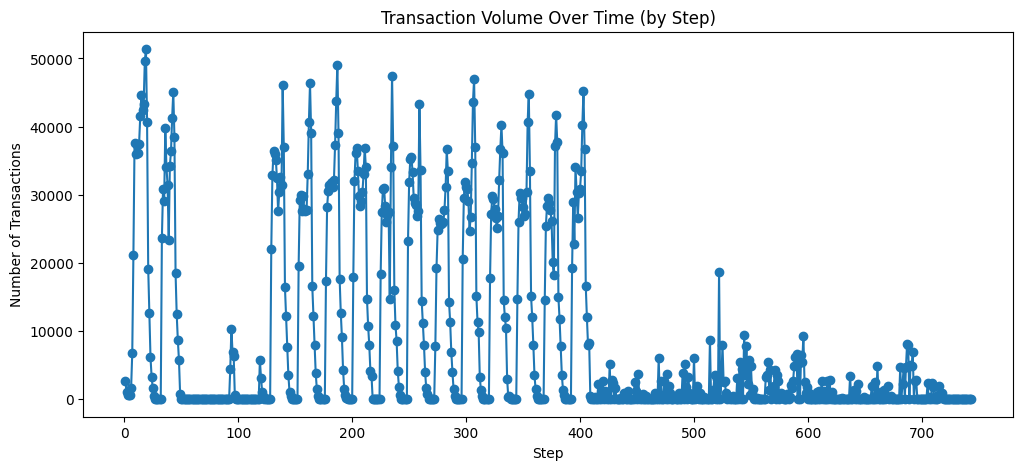

In [ ]:
# 1. Transaction Volume Over Time
# Concept: Detect seasonal or temporal trends in transaction activity. Sudden spikes may indicate fraud bursts.
# Technical Insight: Use time-series aggregation of transaction counts by day/week/month.

# The 'transaction_date' column does not exist. Using 'step' as a proxy for time.
time_series = df.groupby('step').size()

plt.figure(figsize=(12,5))
plt.plot(time_series, marker='o')
plt.title('Transaction Volume Over Time (by Step)')
plt.xlabel('Step')
plt.ylabel('Number of Transactions')
plt.savefig("../images/transaction_volume_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# 2. Fraudulent vs Legitimate Transaction Distribution
# Concept: Compare class imbalance visually. Essential for imbalanced classification problems.
# Technical Insight: Bar charts or pie charts for categorical understanding.

def fraud_distribution(df):

    plt.figure(figsize=(6,4))
    sns.countplot(x="isFraud", data=df)

    plt.title("Fraud vs Non-Fraud Transactions")

    plt.savefig("../images/fraud_distribution.png")

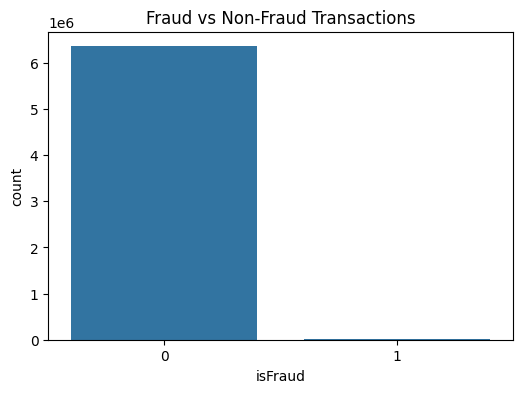

In [ ]:
os.makedirs('../images', exist_ok=True)

fraud_distribution(df)

In [ ]:
# 3. Transaction types Distribution
def transaction_types(df):

    plt.figure(figsize=(8,5))
    sns.countplot(x="type", data=df)

    plt.title("Transaction Types Distribution")

    plt.savefig("../images/transaction_types_distribution.png")

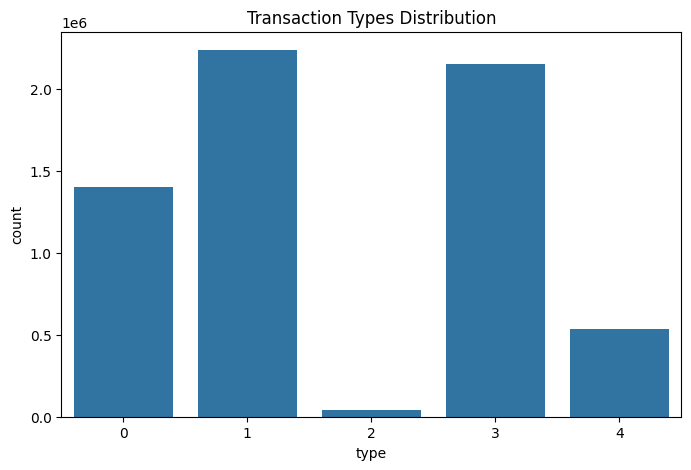

In [ ]:
os.makedirs('../images', exist_ok=True)

transaction_types(df)

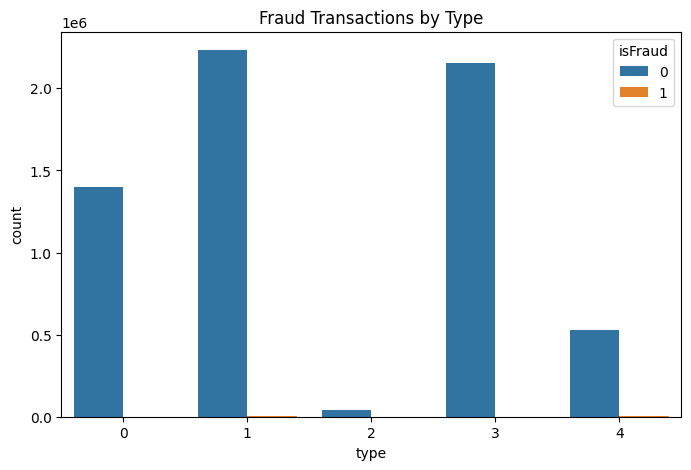

In [ ]:
# 4. Fraud Transaction by Type
plt.figure(figsize=(8,5))

sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud Transactions by Type")

plt.savefig("../images/fraud_by_transaction_type.png", dpi=300, bbox_inches="tight")

plt.show()

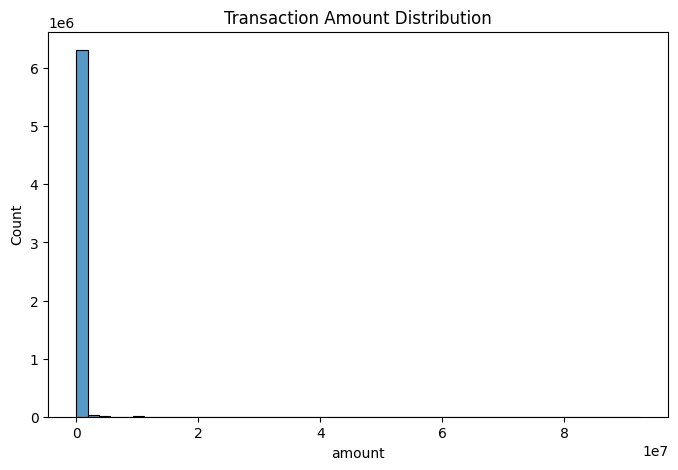

In [ ]:
# 5. Transaction Amount Distribution
# Visualizing transaction amount distribution helps understand
# skewness and the need for feature scaling.

plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.savefig("../images/transaction_amount_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

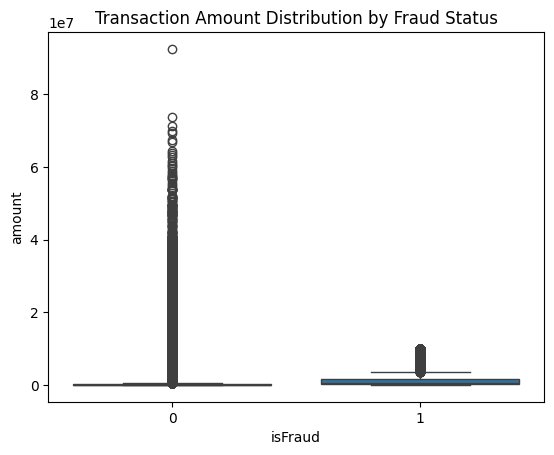

In [ ]:
# 6. Transaction Amount Distribution by Fraud Status
# Concept: Fraud often shows unusual transaction amounts.
# Technical Insight: Boxplots or violin plots highlight outliers and distribution skew.

sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount Distribution by Fraud Status')
plt.savefig("../images/fraud_vs_normal_transaction_amounts.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# 7. Correlation Heatmap
# Concept: Identify relationships between numeric features; helps detect potential predictive features.
# Technical Insight: Strong correlations can guide feature engineering or indicate redundancy.

def correlation_heatmap(df):

    plt.figure(figsize=(10,8))

    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numerical_df.corr(), cmap="rocket", annot=True, fmt=".2f")

    plt.title("Feature Correlation Heatmap")

    plt.savefig("../images/correlation_heatmap.png")

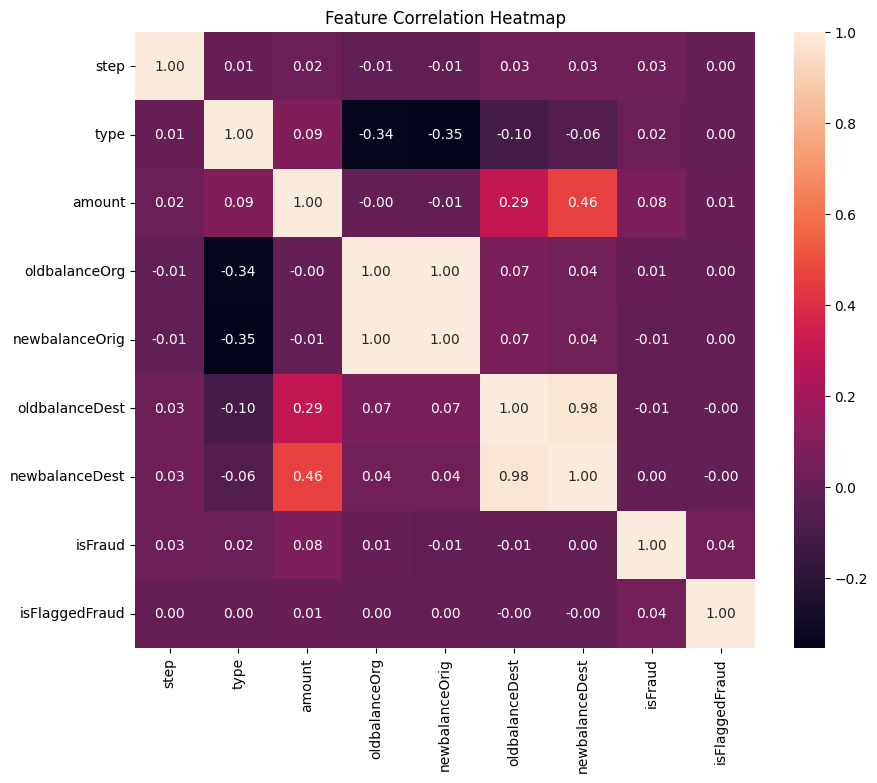

In [ ]:
os.makedirs('../images', exist_ok=True)

correlation_heatmap(df)

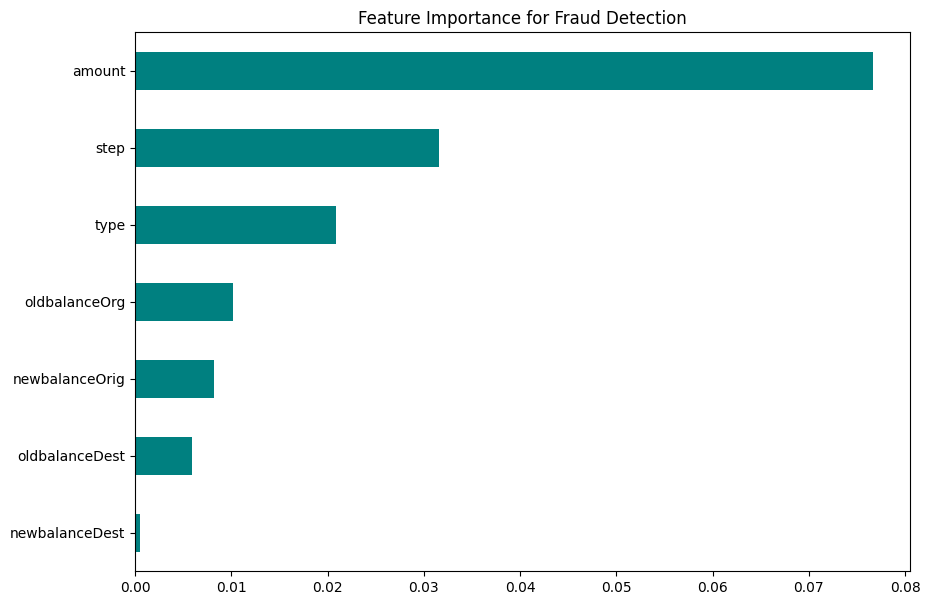

In [ ]:
# 8. Feature Importance using Correlation (No ML model needed)

features = df.drop(columns=['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud'])

importances = features.corrwith(df['isFraud']).abs().sort_values()

importances.plot(kind='barh', figsize=(10, 7), color='teal')
plt.title('Feature Importance for Fraud Detection')
plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
## Key Insights from EDA

# - The dataset is highly imbalanced with fraudulent transactions representing a very small percentage.
# - Certain transaction types such as TRANSFER and CASH_OUT show higher fraud occurrences.
# - Transaction amounts show skewed distribution indicating the presence of large financial transfers.
# - Feature scaling was necessary to normalize transaction-related variables.

## scripts/run_pipeline.py

In [ ]:
def main():

    df = load_dataset("/content/PaySim - Synthetic Financial Dataset for Fraud Detection.csv")

    dataset_shape(df)
    dataset_columns(df)
    dataset_datatypes(df)
    dataset_head(df)
    dataset_description(df)
    missing_values(df)

    df = preprocess_data(df)

    print("\nPREPROCESING COMPLETED!")


if __name__ == "__main__":
    main()

Dataset Loaded Successfully
Shape: (6362620, 11)
Dataset Shape: (6362620, 11)
Columns:
Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')
Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
First 5 Rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT 

## scripts/save_cleaned_dataset.py
Save the cleaned and preprocessed dataset for future model training and analysis.

In [ ]:
import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(os.path.join(output_dir, "processed_paysim.csv"), index=False)

In [ ]:
print(df.head())

   step  type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1     3   9839.64  C1231006815       170136.0       160296.36   
1     1     3   1864.28  C1666544295        21249.0        19384.72   
2     1     4    181.00  C1305486145          181.0            0.00   
3     1     1    181.00   C840083671          181.0            0.00   
4     1     3  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


## Summary

The PaySim dataset was analyzed to understand transaction patterns and fraud behavior. The analysis revealed that fraudulent activities are mainly concentrated in **TRANSFER** and **CASH_OUT** transaction types, while other types show very few fraud cases. Fraudulent transactions often involve large transaction amounts and unusual balance changes, such as accounts being fully drained or destination accounts showing zero balances. The dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of the total data. Based on these observations, the processed dataset is now ready for machine learning models that can handle class imbalance and identify fraud patterns effectively.

### Insights or Next Steps

*   **Feature Engineering Focus**: Prioritize creating features that capture the unique characteristics of 'TRANSFER' and 'CASH\_OUT' transactions, such as flags for `oldbalanceOrg` or `newbalanceOrig` being zero, and interaction terms between 'amount' and `balance_change` features.
*   **Model Strategy for Imbalanced Data**: Given the severe class imbalance (non-fraudulent transactions vastly outnumber fraudulent ones), select models robust to imbalance (e.g., LightGBM, XGBoost with `scale_pos_weight`) and evaluate performance using metrics like precision, recall, and F1-score for the positive (fraud) class. Implement simple rule-based systems to filter out non-fraudulent types and focus detection efforts.